<a href="https://colab.research.google.com/github/AKutergin/dsp-seminars/blob/kutergin/seminars/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №1
## Основы цифровой обработки сигналов: дискретизация, спектральный анализ, алиасинг

**Цель работы:**  
- Освоить базовые приёмы работы с библиотеками NumPy и Matplotlib в Jupyter Notebook.  
- Научиться генерировать различные типы сигналов и анализировать их спектры с помощью быстрого преобразования Фурье (БПФ).  
- Изучить эффект алиасинга и научиться правильно выбирать частоту дискретизации.  

**Необходимое ПО:**  
- Python 3 с установленными пакетами `numpy`, `matplotlib`, `scipy`, `ipywidgets` (для интерактива).  
- Jupyter Notebook / Google Colab.  

**Формат сдачи:**  
- Один Jupyter Notebook с выполненными заданиями, содержащий код, графики и текстовые ответы на вопросы.  
- Имя файла: `1_Фамилия.ipynb`.

## Часть 1. Знакомство с инструментарием

### 1.1. Импорт библиотек и создание временной оси

Выполните в первой ячейке:

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

Создайте временную ось для сигнала длительностью 1 секунду с частотой дискретизации 1000 Гц (т.е. 1000 отсчётов в секунду). Выведите длину массива времени и шаг дискретизации.

In [3]:
fs = 1000          # частота дискретизации, Гц
T = 1              # длительность сигнала, с
t = np.linspace(0, T, fs*T, endpoint=False)  # временная ось
dt = t[T] - t[0]

print(f"Длина массива времени: {len(t)} отсчётов")
print(f"Шаг дискретизации (период): {dt} с")

Длина массива времени: 1000 отсчётов
Шаг дискретизации (период): 0.001 с


**Вопрос 1:** Чему равен период дискретизации $T_s$? Как связаны частота дискретизации $f_s$ и период $T_s$?

Период дискретизации равен {0.001 c}. Частота и период связаны {обратно пропорционально}


### 1.2. Генерация простых сигналов

Сгенерируйте и визуализируйте:
- Синусоидальный сигнал частотой 5 Гц, амплитудой 1.
- Сумму двух синусоид с частотами 5 и 12 Гц и одинаковыми амплитудами.
- Прямоугольный меандр частотой 2 Гц (используйте `signal.square`).

Для каждого сигнала постройте график временной зависимости (первые 0.5 секунды).

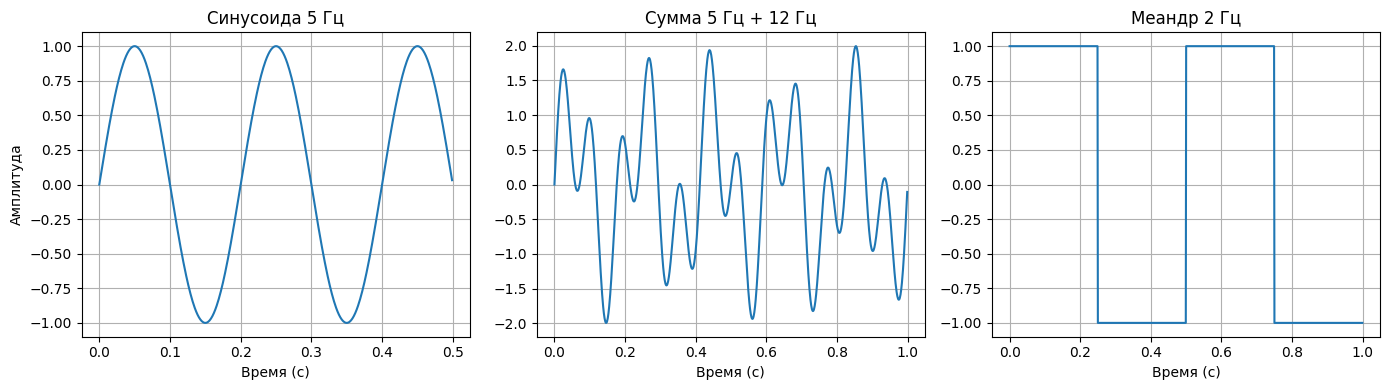

In [4]:
# Синусоида 5 Гц
f1 = 5
sin5 = T * np.sin(2 * np.pi * f1 * t)
lim = int(len(t)/2)

# Сумма синусоид 5 и 12 Гц
f2 = 12
sum_sin = T * np.sin(2 * np.pi * f1 * t) + T * np.sin(2 * np.pi * f2 * t)
sum_sin1 = T * np.sin(2 * np.pi * f1 * t) + T * np.sin(2 * np.pi * f2 * t + 2 * np.pi)

# Меандр 2 Гц
f_meandr = 2
meander = signal.square(2 * np.pi * f_meandr * t)

# Визуализация
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(t[:lim],sin5[:lim])  # первые 0.5 с
plt.title('Синусоида 5 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(t, sum_sin)
plt.title('Сумма 5 Гц + 12 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(t, meander)
plt.title('Меандр 2 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Вопрос 2:** Изменится ли вид суммы синусоид, если одну из них сдвинуть по фазе на 90° ($\pi/2$), на 180° ($\pi$), на 360° ($2\pi$)? (Проверьте на практике, изменив фазу второго сигнала). Объясните результат.

Вид суммы синусоид изменяется, если одну из них сдвинуть по фазе на 90° ( π/2 ) и на 180° ( π ), и не изменяется, если сдвинуть на 360° ( 2π ). Это происходит, поскольку период синусоидлы равен 2π, и она просто возвращает синусоиду в ту же самую фазу

## Часть 2. Спектральный анализ с помощью БПФ

### 2.1. Спектр синусоиды

Для синусоиды частотой 5 Гц вычислите БПФ (`np.fft.fft`). Постройте амплитудный спектр (модуль БПФ) для положительных частот. Не забудьте правильно нормировать амплитуды (поделить на количество отсчётов и учесть, что мы берём половину спектра). Частотную ось получите с помощью `np.fft.fftfreq`.

Подпишите оси: частота (Гц), амплитуда.

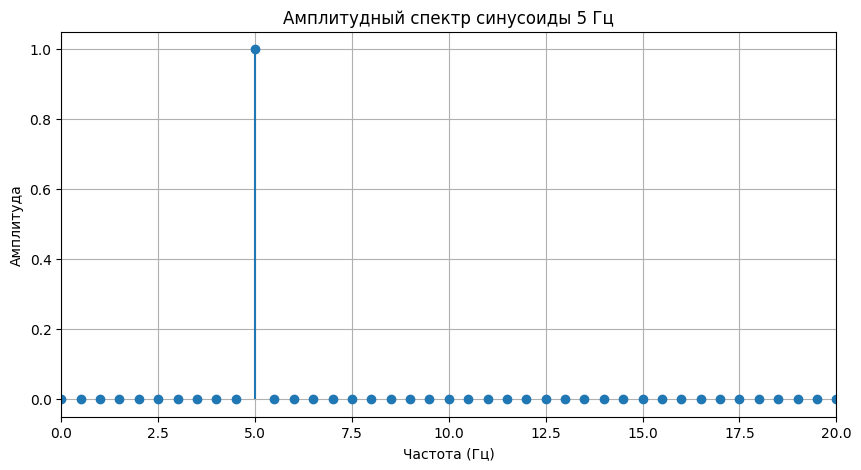

In [7]:
# БПФ синусоиды 5 Гц

t = np.linspace(0, T, fs * T, endpoint=False)
f0 = 5
A = 1.0
signal = A * np.sin(2 * np.pi * f0 * t)
N = len(t)
X = np.fft.fft(signal)
freq = np.fft.fftfreq(N, 1/fs)

# Берём только положительные частоты
half = len(t)//2
X_mag = (2.0 / N) * np.abs(X[:half])  # не забываем про нормировку амплитуды
freq_pos = freq[:half]

plt.figure(figsize=(10, 5))
plt.stem(freq_pos, X_mag, basefmt=" ")
plt.title('Амплитудный спектр синусоиды 5 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

**Вопрос 3:** Почему в спектре присутствует только один пик? Какая должна быть его амплитуда теоретически? Совпадает ли с полученной?

В спектре присутствует только один пик, поскольку сигнал — это чистая гармоника, состоящая только из одной частоты 5Гц. Его теоретическая амплитуда должна быть равна A . Она совпадает с полученной, поскольку использовали нормировку.

### 2.2. Спектр суммы синусоид

Для суммы синусоид (5 и 12 Гц) постройте амплитудный спектр. Убедитесь, что видны два пика на ожидаемых частотах. Измерьте их амплитуды.

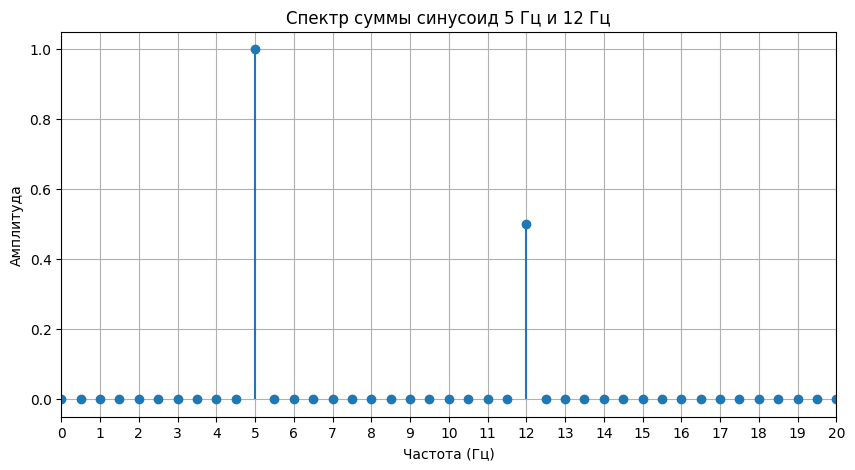

Измеренная амплитуда на 5 Гц: 1.00
Измеренная амплитуда на 12 Гц: 0.50


In [11]:
rand_phase = np.random.uniform(0, 2 * np.pi)

s1 = 1.0 * np.sin(2 * np.pi * 5 * t)
s2 = 0.5 * np.sin(2 * np.pi * 12 * t + rand_phase)
signal_sum = s1 + s2

X_sum = np.fft.fft(signal_sum)
freq = np.fft.fftfreq(N, 1/fs)
X_sum_mag = (2.0 / N) * np.abs(X_sum[:half])

amp_5 = X_sum_mag[np.argmin(np.abs(freq_pos - 5))]
amp_12 = X_sum_mag[np.argmin(np.abs(freq_pos - 12))]

plt.figure(figsize=(10, 5))
plt.stem(freq_pos, X_sum_mag, basefmt=" ", linefmt='C0-', markerfmt='C0o')
plt.title('Спектр суммы синусоид 5 Гц и 12 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 1))
plt.grid(True)
plt.show()

print(f"Измеренная амплитуда на 5 Гц: {amp_5:.2f}")
print(f"Измеренная амплитуда на 12 Гц: {amp_12:.2f}")

**Вопрос 4:** Изменится ли амплитудный спектр, если фазы сигналов изменить? Проверьте, задав для одного из них случайную фазу.

Если изменить фазы сигналов, то амплитудный спектр не изменится.

### 2.3. Спектр меандра

Постройте амплитудный спектр меандра частотой 2 Гц. Сравните с теоретическим представлением: меандр состоит из нечётных гармоник с убывающими амплитудами $(1, 1/3, 1/5,\dots)\cdot 4/\pi$.

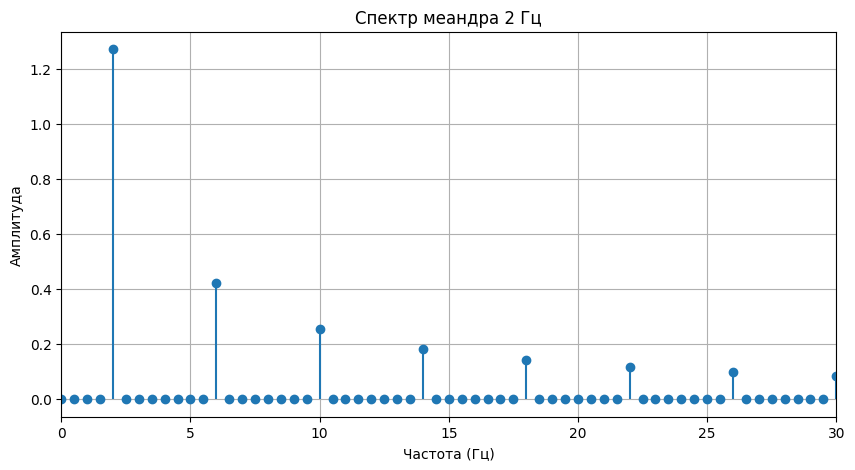

Гармоника    | Частота    | Измерено   | Теория (4/π * 1/n)
------------------------------------------------------------
1            | 2          | 1.2732     | 1.2732
3            | 6          | 0.4244     | 0.4244
5            | 10         | 0.2547     | 0.2546


In [20]:

f_square = 2
y_meander = signal.square(2 * np.pi * f_square * t)

X_meander = np.fft.fft(y_meander)
X_meander_mag = (2.0 / N) * np.abs(X_meander[:N//2])
freq_pos = np.fft.fftfreq(N, 1/fs)[:N//2]

plt.figure(figsize=(10, 5))
plt.stem(freq_pos, X_meander_mag, basefmt=" ")
plt.title('Спектр меандра 2 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 30)
plt.grid(True)
plt.show()

# Сравнение с теорией для первых трёх гармоник
harmonics = [1, 3, 5]
print(f"{'Гармоника':<12} | {'Частота':<10} | {'Измерено':<10} | {'Теория (4/π * 1/n)'}")
print("-" * 60)
for n in harmonics:
    f_n = n * f_square
    measured = X_meander_mag[np.argmin(np.abs(freq_pos - f_n))]
    theory = (4 / np.pi) * (1 / n)
    print(f"{n:<12} | {f_n:<10} | {measured:<10.4f} | {theory:.4f}")


**Вопрос 5:** Почему в спектре меандра присутствуют только нечётные гармоники? Покажите, что амплитуды гармоник совпадают с теоретическим значением.

В спектре присутствуют только нечётные гармоники, поскольку менадр обладает свойстовм антифазы

Вычислим теоретические амплитуды нескольких первых гармоник: $A_n = \frac{4}{\pi \cdot n}$

Для $n=1$ : $A_1 = \frac{4}{\pi \cdot 1} \approx 1.2732$
Для $n=3$: $A_3 = \frac{4}{\pi \cdot 3} \approx 0.4244$
Для $n=5$: $A_5 = \frac{4}{\pi \cdot 5} \approx 0.2546$

При численном вычислении Фурье-преобразования получились следующие значения амплитуд гармоник: 1.2732 для 2 Гц, 0.4244 для 6 Гц и 0.2547 для 10 Гц.

Видим, что результаты вычислений совпадают с теоретическими значениями.

## Часть 3. Дискретизация и алиасинг

### 3.1. Корректная и некорректная дискретизация

Создайте «аналоговый» сигнал — синусоиду частотой 8 Гц, но с очень высокой частотой дискретизации (например, 1000 Гц), чтобы он выглядел гладким.

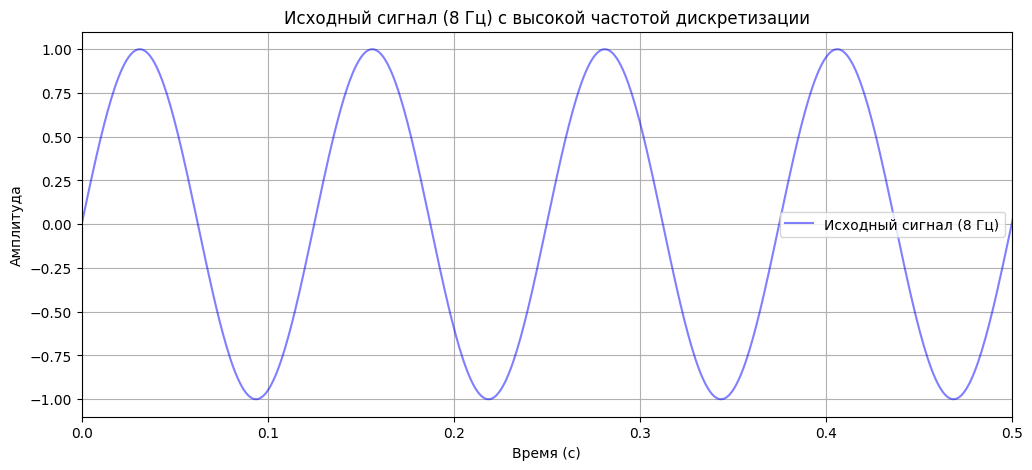

In [21]:
# «Аналоговый» сигнал с высокой частотой дискретизации
fs_analog = 1000
T = 1.0  # общая длительность
t_analog = np.linspace(0, T, fs_analog, endpoint=False)
f_signal = 8
analog_signal = np.sin(2 * np.pi * f_signal * t_analog)

plt.figure(figsize=(12, 5))
plt.plot(t_analog, analog_signal, 'b-', alpha=0.5, label='Исходный сигнал (8 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Исходный сигнал (8 Гц) с высокой частотой дискретизации')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

Теперь выполните его дискретизацию с двумя разными частотами:
- $f_{s1} = 50$ Гц (заведомо больше удвоенной частоты сигнала, 2·8=16 Гц);
- $f_{s2} = 12$ Гц (меньше 16 Гц).

Для этого создайте новые временные оси с шагом $1/f_{s1}$ и $1/f_{s2}$ и вычислите значения синусоиды в этих точках.

На одном графике изобразите:
- исходный гладкий сигнал (тонкая линия);
- отсчёты при корректной дискретизации (маркеры);
- отсчёты при алиасинге (маркеры другого цвета).

Также постройте сигнал, который «воспринимается» после дискретизации с малой частотой.

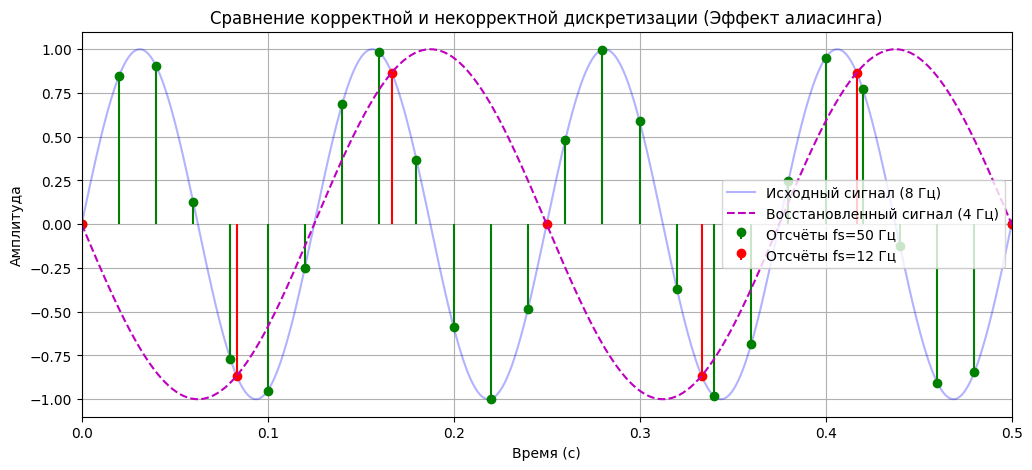

In [22]:
# Частоты дискретизации для эксперимента
fs1 = 50
fs2 = 12

# Отсчёты при корректной дискретизации
t1 = np.arange(0, T, 1/fs1)
samples1 = np.sin(2 * np.pi * f_signal * t1)

# Отсчёты при некорректной дискретизации (алиасинг)
t2 = np.arange(0, T, 1/fs2)
samples2 = np.sin(2 * np.pi * f_signal * t2)

f_alias = abs(f_signal - fs2)
t_alias = np.linspace(0, T, 1000)
alias_signal = -np.sin(2 * np.pi * f_alias * t_alias)

plt.figure(figsize=(12, 5))

# Исходный сигнал
plt.plot(t_analog, analog_signal, 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')

# Отсчеты fs1
plt.stem(t1, samples1, linefmt='g-', markerfmt='go', basefmt=' ', label=f'Отсчёты fs={fs1} Гц')

# Отсчеты fs2
plt.stem(t2, samples2, linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Отсчёты fs={fs2} Гц')

# Восстановленный ложный сигнал
plt.plot(t_alias, alias_signal, 'm--', label=f'Восстановленный сигнал ({f_alias} Гц)')

plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сравнение корректной и некорректной дискретизации (Эффект алиасинга)')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

**Вопрос 6:** Какая частота «кажется» присутствующей в сигнале при $f_{s2}=12$ Гц? Совпадает ли она с предсказанной теоретически? (Подсказка: формула алиасинга $f_{alias} = |f - k f_s|$, выберите $k$ так, чтобы $f_{alias}$ лежала в интервале $[0, f_s/2]$.)

В сигнале при $f_{s2}=12$ Гц кажется, что присутствует частота 4 Гц. Она совпадает с теоретической: $f_{alias}=|f-kf_s|=$ $|8 - 1 \cdot 12| = 4$ Гц при $k=$ 1.

### 3.2. Интерактивная демонстрация алиасинга

Используя `ipywidgets.interact`, создайте интерактивный график, где можно менять частоту сигнала и частоту дискретизации ползунками, и сразу видеть исходный сигнал, отсчёты и восстановленный сигнал. Пример такого кода был на лекции.

Добейтесь, чтобы при нарушении условия Найквиста явно проявлялся алиасинг (восстановленный сигнал имел более низкую частоту, чем исходный).

In [24]:
def plot_aliasing(f_signal=8.0, f_sampling=12.0):
    t_analog = np.linspace(0, T, fs_analog, endpoint=False)
    y_analog = np.sin(2 * np.pi * f_signal * t_analog)
    t_samples = np.arange(0, T, 1/f_sampling)
    y_samples = np.sin(2 * np.pi * f_signal * t_samples)
    k = round(f_signal / f_sampling)
    f_alias = abs(f_signal - k * f_sampling)
    sign = np.sign(f_signal - k * f_sampling)
    y_alias = sign * np.sin(2 * np.pi * f_alias * t_analog)

    plt.figure(figsize=(12, 5))

    # Исходный сигнал
    plt.plot(t_analog, y_analog, 'b-', alpha=0.3, label=f'Исходный ({f_signal} Гц)')

    # Точки дискретизации
    plt.stem(t_samples, y_samples, linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Отсчёты fs={f_sampling} Гц')

    # Восстановленный сигнал
    plt.plot(t_analog, y_alias, 'm--', linewidth=2, label=f'Восстановленный ({f_alias:.1f} Гц)')

    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.title(f'Алиасинг: f_sig = {f_signal} Гц, fs = {f_sampling} Гц')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.xlim(0, 0.5)
    plt.ylim(-1.1, 1.1)
    plt.show()

# Настройка интерактивных элементов
widgets.interact(plot_aliasing,
    f_signal=widgets.FloatSlider(min=1, max=30, step=0.5, value=8.0, description='f сигнала:'),
    f_sampling=widgets.FloatSlider(min=2, max=60, step=1.0, value=12.0, description='f дискр. (fs):')
);

interactive(children=(FloatSlider(value=8.0, description='f сигнала:', max=30.0, min=1.0, step=0.5), FloatSlid…

**Вопрос 7:** При каких соотношениях частоты сигнала и частоты дискретизации алиасинг наиболее заметен? Что происходит, когда частота сигнала в точности равна половине частоты дискретизации?

Алиасинг наиболее заметен, когда частота дискретизации $f_s$ лишь ненамного превышает частоту сигнала $f$ или когда она меньше удвоенной частоты сигнала.

Когда частота сигнала в точности равна половине частоты дискретизации, то результат зависит от фазы: если отсчёты приходятся на максимумы и минимумы, мы увидим меандр или знакочередующуюся последовательность, но если отсчёты попадут в «нули» синусоиды, сигнал полностью исчезнет (амплитуда станет нулевой)..